# Advanced LSTM v3: Diagnostic & Feature Refinement
## Strategy: Breaking the Lag and Capturing Real Alpha

This version focuses on diagnosing why the model might be lagging and introduces high-alpha microstructure factors.

In [95]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sns.set(style="whitegrid")

## 1. Feature Engineering: Beyond Simple Returns

In [96]:
ohlcv = pd.read_parquet('../data/mainnet_weth_usdc/curated/pool_ohlcv_hour.parquet')
edges = pd.read_parquet('../data/mainnet_weth_usdc/curated/market_edges_hour.parquet')

df = ohlcv.sort_values('timestamp').merge(edges, on='timestamp', suffixes=('', '_edge'))
df = df.set_index('timestamp')

# --- 1. Momentum & Acceleration ---
df['returns'] = np.log(df['sell_price_usd'] / df['sell_price_usd'].shift(1))
df['accel'] = df['returns'] - df['returns'].shift(1)

# --- 2. Microstructure: Volume-Weighted Spread ---
df['vw_spread'] = df['observed_spread_bps'] * np.log1p(df['volume_usd'])

# --- 3. RSI ---
def calculate_rsi(series, period=14):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

df['rsi'] = calculate_rsi(df['sell_price_usd'])

# Target: Next Hour Returns
df['target'] = df['returns'].shift(-1)

df = df.dropna()
print(f"Rows: {len(df)}")

Rows: 716


## 2. Model Training

In [ ]:
feature_cols = ['returns', 'accel', 'vw_spread', 'rsi', 'observed_spread_bps']
scaler_x, scaler_y = StandardScaler(), StandardScaler()
raw_split_idx = int(0.8 * len(df))

scaler_x, scaler_y = StandardScaler(), StandardScaler()

scaler_x.fit(df[feature_cols].iloc[:raw_split_idx])
scaler_y.fit(df[['target']].iloc[:raw_split_idx])

scaled_x = scaler_x.transform(df[feature_cols])
scaled_y = scaler_y.transform(df[['target']])


def create_sequences(x, y, window=24):
    X_s, y_s = [], []
    for i in range(len(x)-window):
        X_s.append(x[i:i+window])
        y_s.append(y[i+window])
    return np.array(X_s), np.array(y_s)

X, y = create_sequences(scaled_x, scaled_y)
seq_split_idx = int(0.8 * len(X))

X_train = torch.tensor(X[:seq_split_idx], dtype=torch.float32).to(device)
X_test = torch.tensor(X[seq_split_idx:], dtype=torch.float32).to(device)
y_train = torch.tensor(y[:seq_split_idx], dtype=torch.float32).to(device)
y_test = torch.tensor(y[seq_split_idx:], dtype=torch.float32).to(device)


class MultiFactorLSTM(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.lstm = nn.LSTM(input_size, 64, 2, batch_first=True, dropout=0.3)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

model = MultiFactorLSTM(len(feature_cols)).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
criterion = nn.SmoothL1Loss()

for epoch in range(250):
    model.train()
    optimizer.zero_grad()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    loss.backward()
    optimizer.step()

## 3. Comprehensive Visualization

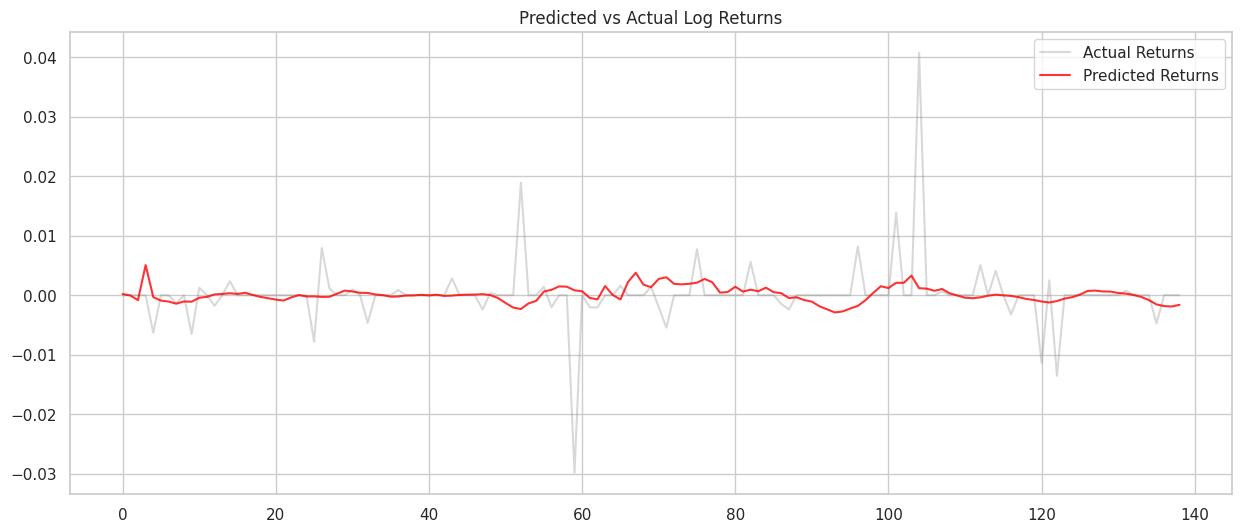

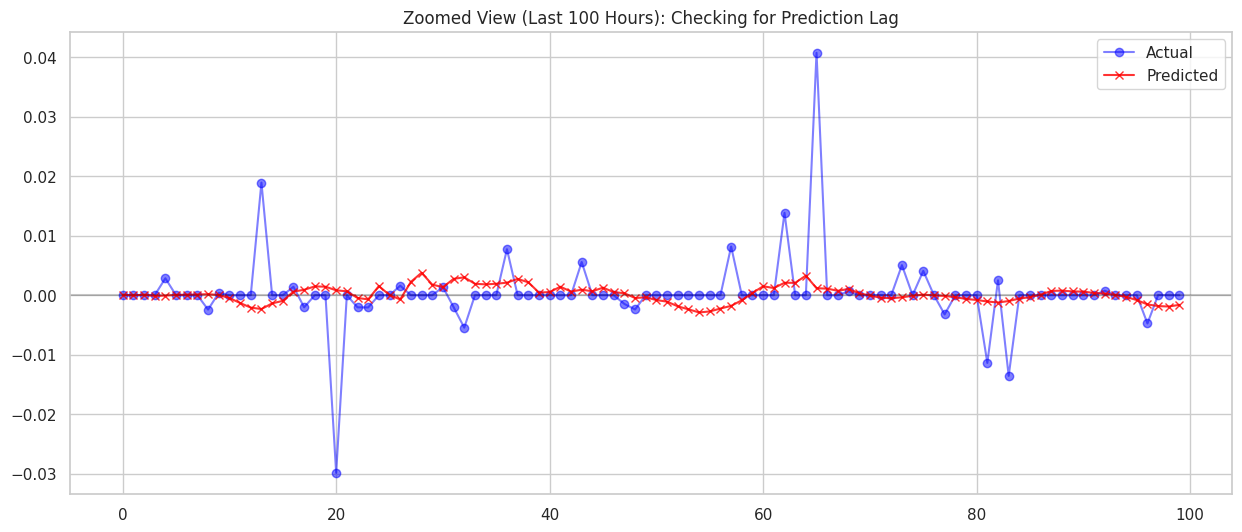

In [115]:
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test).cpu().numpy()
    preds = scaler_y.inverse_transform(preds_scaled).flatten()
    actuals = scaler_y.inverse_transform(y_test.cpu().numpy()).flatten()

# 1. Full comparison
plt.figure(figsize=(15, 6))
plt.plot(actuals, label='Actual Returns', color='gray', alpha=0.3)
plt.plot(preds, label='Predicted Returns', color='red', alpha=0.8)
plt.title('Predicted vs Actual Log Returns')
plt.legend()
plt.show()

# 2. Zoomed View (Detecting Lag)
plt.figure(figsize=(15, 6))
plt.plot(actuals[-100:], label='Actual', color='blue', marker='o', alpha=0.5)
plt.plot(preds[-100:], label='Predicted', color='red', marker='x', alpha=0.8)
plt.axhline(0, color='black', alpha=0.2)
plt.title('Zoomed View (Last 100 Hours): Checking for Prediction Lag')
plt.legend()
plt.show()

## 4. Final Optimized Backtest with Position Visualization

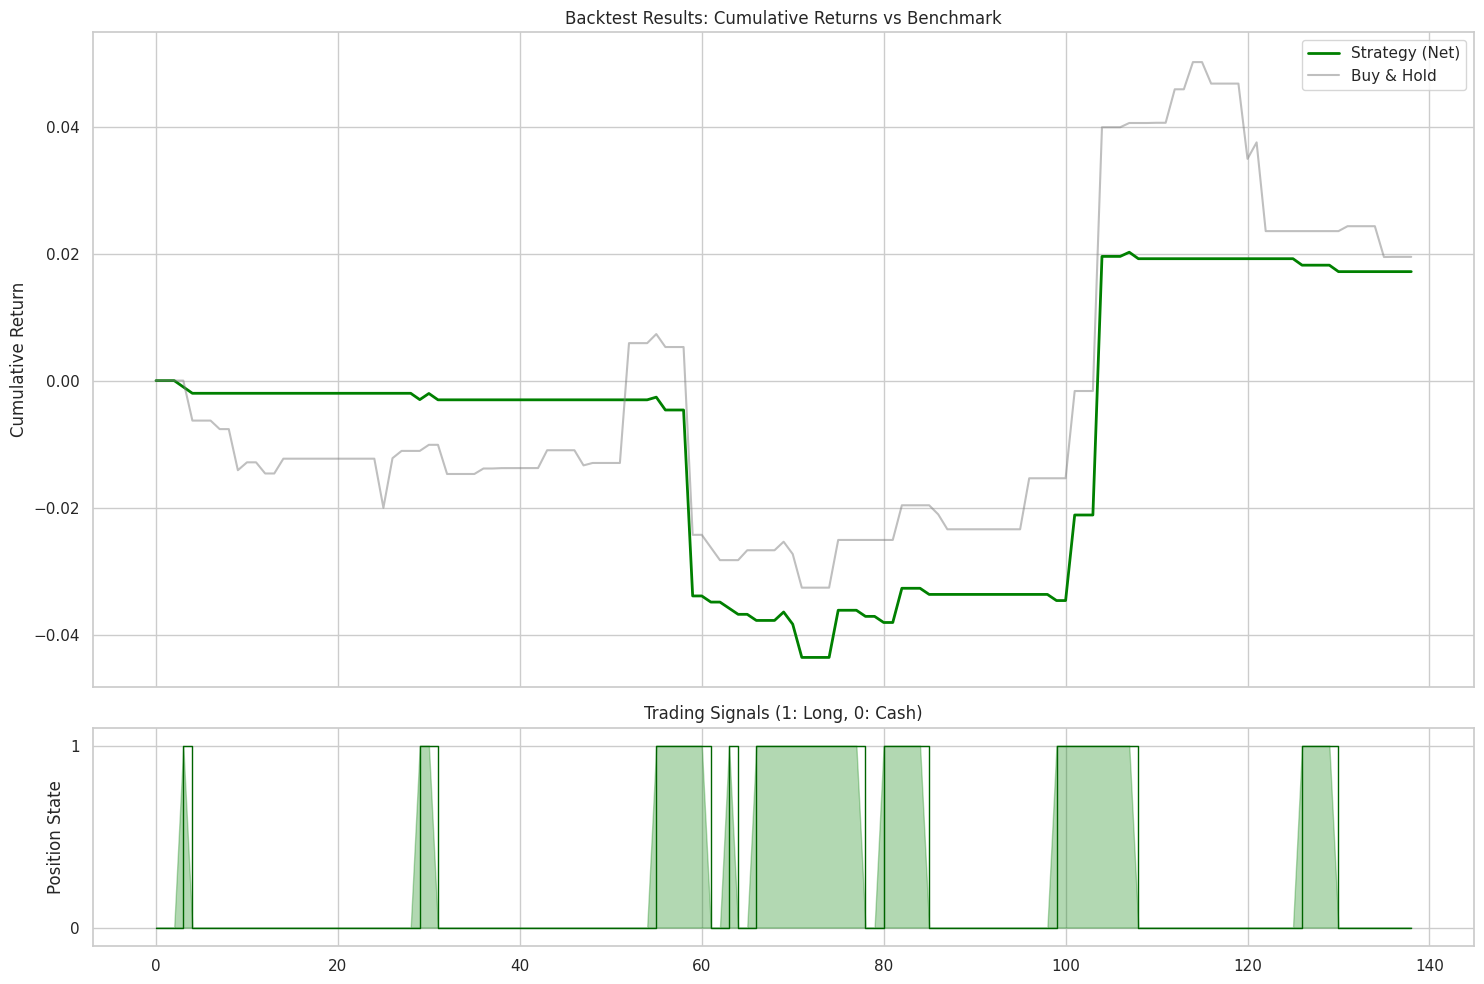

Strategy Final Return: 1.72%
Time in Market: 28.78%


array([ 0.        ,  0.        ,  0.        , -0.0009995 , -0.001998  ,
       -0.001998  , -0.001998  , -0.001998  , -0.001998  , -0.001998  ,
       -0.001998  , -0.001998  , -0.001998  , -0.001998  , -0.001998  ,
       -0.001998  , -0.001998  , -0.001998  , -0.001998  , -0.001998  ,
       -0.001998  , -0.001998  , -0.001998  , -0.001998  , -0.001998  ,
       -0.001998  , -0.001998  , -0.001998  , -0.001998  , -0.0029955 ,
       -0.00202939, -0.00302686, -0.00302686, -0.00302686, -0.00302686,
       -0.00302686, -0.00302686, -0.00302686, -0.00302686, -0.00302686,
       -0.00302686, -0.00302686, -0.00302686, -0.00302686, -0.00302686,
       -0.00302686, -0.00302686, -0.00302686, -0.00302686, -0.00302686,
       -0.00302686, -0.00302686, -0.00302686, -0.00302686, -0.00302686,
       -0.00260691, -0.004628  , -0.004628  , -0.004628  , -0.03390633,
       -0.03390633, -0.03487194, -0.03487194, -0.03583659, -0.03680027,
       -0.03680027, -0.03776299, -0.03776299, -0.03776299, -0.03

In [ ]:
def final_backtest(actuals, preds, fee_bps=10):
    # Confidence Threshold
    threshold = 0.5 * (2 * fee_bps) / 10000.0
    signals = (preds > threshold).astype(int)
    
    # Calculate Returns
    rets = signals * actuals
    trades = np.diff(signals, prepend=0) != 0
    net_rets = rets - (trades * fee_bps / 10000.0)
    
    cum_strat = np.exp(np.cumsum(net_rets)) - 1
    cum_bh = np.exp(np.cumsum(actuals)) - 1
    
    # --- DUAL AXIS PLOT ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    
    # Subplot 1: Cumulative Returns
    ax1.plot(cum_strat, label='Strategy (Net)', color='green', lw=2)
    ax1.plot(cum_bh, label='Buy & Hold', color='gray', alpha=0.5)
    ax1.set_ylabel('Cumulative Return')
    ax1.set_title('Backtest Results: Cumulative Returns vs Benchmark')
    ax1.legend()
    
    # Subplot 2: Position States (1=Long, 0=Cash)
    ax2.fill_between(range(len(signals)), 0, signals, color='green', alpha=0.3)
    ax2.step(range(len(signals)), signals, where='post', color='darkgreen', lw=1)
    ax2.set_ylabel('Position State')
    ax2.set_yticks([0, 1])
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_title('Trading Signals (1: Long, 0: Cash)')
    
    plt.tight_layout()
    plt.show()
    
    print(f"Strategy Final Return: {cum_strat[-1]*100:.2f}%")
    print(f"Time in Market: {signals.mean()*100:.2f}%")
    return cum_strat

final_backtest(actuals, preds)